# 09 — Longitudinal Trends in Retention

**Chapter 11 companion.** Did first-year retention fall for students who entered
college during the pandemic, and did it recover? Answering that from IPEDS requires
stacking six annual releases correctly, deciding which institutions to follow, and
separating change within institutions from change in which institutions report.
The notebook then works through a second, shorter series: published tuition and
fees.

| | |
|---|---|
| Input | `EF2018D` to `EF2023D` (six fall releases); `data/analytic/institutions_2023.parquet` for sector; `IC2023_AY` for tuition |
| Outcome | `RET_PCF`: full-time retention rate, fall-to-fall |
| Methods | Vintage stacking with reference-period checks, balanced vs unbalanced panels, two-way fixed effects with clustered standard errors, event-study coefficients by sector, compound annual growth |

**Timing.** A retention rate in the fall `t` release describes students who entered
in fall `t - 1` and returned in fall `t`. EF2021D is therefore the fall-2020
entering cohort, the first to begin college during the pandemic. The notebook
indexes everything by entering cohort to keep that straight.

In [1]:
import os
import sys
import warnings
from pathlib import Path

sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ipeds_utils as iu

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams.update({
    "figure.dpi": 100, "figure.figsize": (8, 4.2),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.25, "font.size": 10,
})

ANALYTIC = Path("../data/analytic")
FIGURES = Path("../reports/figures")
ANALYTIC.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

SEED = 20231  # one seed for every stochastic step, so reruns reproduce exactly
rng = np.random.default_rng(SEED)


def save(name):
    """Save the current figure to reports/figures and display it."""
    plt.tight_layout()
    plt.savefig(FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


print(f"ipeds_utils {iu.__version__} | pandas {pd.__version__} | numpy {np.__version__}")

ipeds_utils 1.1.0 | pandas 3.0.5 | numpy 2.5.3


In [2]:
source = ANALYTIC / "institutions_2023.parquet"
if not source.exists():
    raise FileNotFoundError("Run 01_ingest_clean_deidentify.ipynb first; it builds the analytic table.")

inst = pd.read_parquet(source)
inst = inst[inst["IN_UNIVERSE"]].copy()
print(f"{len(inst):,} institutions in the analysis universe")

5,988 institutions in the analysis universe


## 1. Stack the vintages

`iu.stack_vintages` fetches each release (revised versions where NCES published
one), asserts that each dictionary's reference period reads "Fall {year}", and
refuses duplicate institution-years. A mislabelled or shifted file fails here
rather than appearing as a trend break.

In [3]:
panel, provenance = iu.stack_vintages("EF{year}D", range(2018, 2024), ["RET_PCF", "STUFACR", "RRFTCTA"],
                                      raw_dir="../data/raw")
panel["COHORT"] = panel["YEAR"] - 1
panel = panel.merge(inst[["UNITID", "SECTOR", "SECTOR_LABEL"]], on="UNITID", how="inner")
print(pd.DataFrame(provenance)[["table", "period_check"]].to_string(index=False))
panel.groupby("COHORT")["RET_PCF"].agg(["size", "count", "median"]).rename(
    columns={"size": "institution rows", "count": "with retention", "median": "median retention"})

  table period_check
EF2018D    Fall 2018
EF2019D    Fall 2019
EF2020D    Fall 2020
EF2021D    Fall 2021
EF2022D    Fall 2022
EF2023D    Fall 2023


,institution rows,with retention,median retention
COHORT,,,
2017,5373,4793,72.000
2018,5424,4820,73.000
2019,5505,4910,73.000
2020,5554,4921,71.000
2021,5637,5011,73.000
2022,5646,5004,74.000


Sector is taken from 2023 and assumed fixed. That is nearly always true, but an
institution that converted from for-profit to nonprofit would be classified by its
current status for every year. The merge also keeps only institutions still in the
2023 universe. Closures appear as institutions that stop reporting, which the
unbalanced panel reflects and the balanced panel removes.

## 2. Composition versus change: balanced and unbalanced panels

An unbalanced sector mean can move because institutions improve, or because the
set of reporting institutions changes. The balanced panel keeps only institutions
with a retention rate for every cohort, so any movement in its mean is change
within institutions.

unbalanced: 3,368 institutions; balanced: 2,732 observed in all 6 cohorts


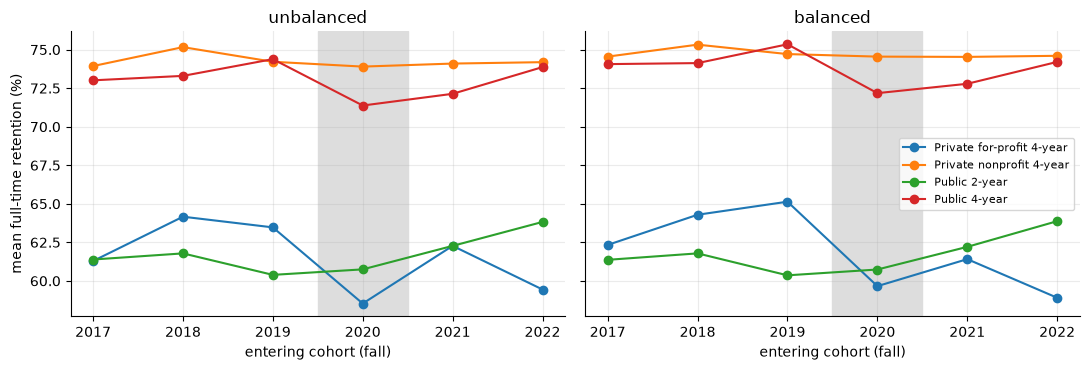

In [4]:
sectors = {1: "Public 4-year", 2: "Private nonprofit 4-year", 3: "Private for-profit 4-year", 4: "Public 2-year"}
panel = panel[panel["SECTOR"].isin(sectors)].assign(sector=lambda d: d["SECTOR"].map(sectors))
bal = iu.balanced(panel, "RET_PCF")
print(f"unbalanced: {panel['UNITID'].nunique():,} institutions; "
      f"balanced: {bal['UNITID'].nunique():,} observed in all {panel['COHORT'].nunique()} cohorts")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, data, title in ((axes[0], panel, "unbalanced"), (axes[1], bal, "balanced")):
    for name, g in data.groupby("sector"):
        ax.plot(g.groupby("COHORT")["RET_PCF"].mean(), "o-", label=name)
    ax.axvspan(2019.5, 2020.5, color="#DDDDDD", zorder=0)
    ax.set(title=title, xlabel="entering cohort (fall)")
axes[0].set_ylabel("mean full-time retention (%)")
axes[1].legend(fontsize=8)
save("09_balanced_vs_unbalanced")

In [5]:
trend = pd.concat({
    "unbalanced": panel.groupby(["sector", "COHORT"])["RET_PCF"].mean().unstack(),
    "balanced": bal.groupby(["sector", "COHORT"])["RET_PCF"].mean().unstack(),
})
trend.round(1)

COHORT                                 2017   2018   2019   2020   2021   2022
           sector                                                             
unbalanced Private for-profit 4-year 61.300 64.200 63.500 58.500 62.300 59.400
           Private nonprofit 4-year  73.900 75.200 74.200 73.900 74.100 74.200
           Public 2-year             61.400 61.800 60.400 60.700 62.300 63.800
           Public 4-year             73.000 73.300 74.400 71.400 72.100 73.900
balanced   Private for-profit 4-year 62.300 64.300 65.100 59.700 61.400 58.900
           Private nonprofit 4-year  74.600 75.300 74.700 74.600 74.500 74.600
           Public 2-year             61.400 61.800 60.400 60.700 62.200 63.900
           Public 4-year             74.100 74.100 75.300 72.200 72.800 74.200

Both panels show the same shape, but not the same levels. The balanced means sit
0.1 to 1.1 points higher for four-year publics and nonprofits, because institutions
that report every year are more established. In public two-year colleges the two panels
are nearly identical, since almost all of them report every year. Before reading a
trend, check that it survives balancing. The for-profit series moves most between
the two, because its membership turns over most.

## 3. Two-way fixed effects and an event study

Institution fixed effects remove every stable institutional difference. Cohort
dummies then trace the average within-institution change relative to a reference
cohort. The reference is the fall-2018 cohort, the last to complete its first year
before the pandemic. The fall-2019 cohort's return in fall 2020 was already
disrupted.

The model is estimated on the within-transformed balanced panel. Standard errors are
clustered by institution, since the same institution's years are correlated.
Estimating each sector separately gives the sector interactions directly.

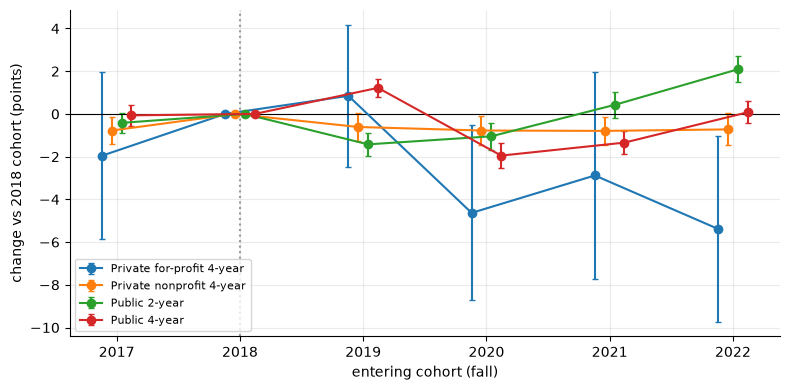

,Private for-profit 4-year,Private nonprofit 4-year,Public 2-year,Public 4-year
2017,"-1.96 [-5.88, +1.96]","-0.78 [-1.40, -0.16]","-0.42 [-0.90, +0.06]","-0.07 [-0.55, +0.42]"
2018,"+0.00 [+0.00, +0.00]","+0.00 [+0.00, +0.00]","+0.00 [+0.00, +0.00]","+0.00 [+0.00, +0.00]"
2019,"+0.85 [-2.48, +4.17]","-0.61 [-1.28, +0.06]","-1.42 [-1.96, -0.89]","+1.22 [+0.79, +1.65]"
2020,"-4.63 [-8.73, -0.53]","-0.78 [-1.44, -0.11]","-1.05 [-1.69, -0.40]","-1.95 [-2.52, -1.38]"
2021,"-2.88 [-7.73, +1.97]","-0.79 [-1.45, -0.14]","+0.42 [-0.20, +1.05]","-1.34 [-1.88, -0.81]"
2022,"-5.38 [-9.72, -1.04]","-0.72 [-1.48, +0.03]","+2.09 [+1.48, +2.70]","+0.08 [-0.43, +0.58]"


In [6]:
import statsmodels.api as sm

REF = 2018


def event_study(data):
    d = data.dropna(subset=["RET_PCF"]).copy()
    dummies = pd.get_dummies(d["COHORT"], prefix="c", dtype=float).drop(columns=f"c_{REF}")
    d = pd.concat([d, dummies], axis=1)
    cols = ["RET_PCF", *dummies.columns]
    w = iu.within_transform(d, "UNITID", cols)
    fit = sm.OLS(w["RET_PCF"], w[dummies.columns]).fit(cov_type="cluster", cov_kwds={"groups": w["UNITID"]})
    ci = fit.conf_int()
    out = pd.DataFrame({"estimate": fit.params, "lo": ci[0], "hi": ci[1]})
    out.index = [int(c.split("_")[1]) for c in out.index]
    out.loc[REF] = 0.0
    return out.sort_index()


effects = {name: event_study(g) for name, g in bal.groupby("sector")}
fig, ax = plt.subplots(figsize=(8, 4))
for i, (name, e) in enumerate(effects.items()):
    x = e.index + (i - 1.5) * 0.08
    ax.errorbar(x, e["estimate"], yerr=[e["estimate"] - e["lo"], e["hi"] - e["estimate"]],
                fmt="o-", capsize=2, label=name)
ax.axhline(0, color="k", lw=0.8)
ax.axvline(REF, color="#999999", ls=":")
ax.set(xlabel="entering cohort (fall)", ylabel=f"change vs {REF} cohort (points)")
ax.legend(fontsize=8)
save("09_event_study")
pd.concat({k: v.apply(lambda r: f"{r['estimate']:+.2f} [{r['lo']:+.2f}, {r['hi']:+.2f}]", axis=1)
           for k, v in effects.items()}, axis=1)

The timing of the dip differs by sector, and the cohort indexing makes that visible:

- **Public two-year colleges** dip first. The fall-2019 cohort, whose return in fall
  2020 fell in the first pandemic autumn, is 1.4 points below the reference, and
  the fall-2020 cohort about 1 point below. By the fall-2022 cohort retention is
  2.1 points above the pre-pandemic level.
- **Public four-year institutions** peak with the fall-2019 cohort (+1.2) and dip
  with the fall-2020 cohort (-2.0). They are back to the reference by the fall-2022
  cohort, with the interval spanning zero.
- **Private nonprofits** sit a steady 0.6 to 0.8 points below the reference in
  every cohort after it, including 2017. That is a flat series with a high
  reference year, not a pandemic effect.
- **For-profit four-year institutions** show the largest estimated declines
  (-4.6 and -5.4 points), with no recovery by the fall-2022 cohort. The intervals
  are several points wide, since the balanced group is small and heterogeneous.

These are within-institution changes among survivors. They describe what happened
at institutions that kept reporting, not the sector as it existed in 2018.

## 4. Tuition trajectories: a short wide series

`IC2023_AY` carries four years of published in-state tuition and fees in one file:
`CHG2AY0` (2020-21) to `CHG2AY3` (2023-24). Wide-to-long reshaping turns it into a
panel. Compound annual growth summarises each institution's trajectory, and growth
is nominal. Deflating needs an external price index, which is exercise 2.

In [7]:
record = iu.fetch("IC2023_AY", raw_dir="../data/raw")
ay = iu.read_csv(record["data_path"], usecols=["UNITID", "CHG2AY0", "CHG2AY1", "CHG2AY2", "CHG2AY3"])
long = ay.melt(id_vars="UNITID", var_name="item", value_name="price")
long["YEAR"] = long["item"].str[-1].astype(int).map({0: 2020, 1: 2021, 2: 2022, 3: 2023})
complete = long.dropna(subset=["price"]).query("price > 0").groupby("UNITID").filter(lambda g: len(g) == 4)

wide = complete.pivot(index="UNITID", columns="YEAR", values="price")
wide["CAGR"] = (wide[2023] / wide[2020]) ** (1 / 3) - 1
wide = wide.join(inst.set_index("UNITID")[["CONTROL_LABEL", "ICLEVEL"]], how="inner")
wide["level"] = wide["ICLEVEL"].map({1: "4-year", 2: "2-year", 3: "less than 2-year"})
print(f"{len(wide):,} institutions with four positive published prices")
wide.groupby(["CONTROL_LABEL", "level"])["CAGR"].describe()[["count", "25%", "50%", "75%"]].mul(
    [1, 100, 100, 100]).round(2).rename(columns=lambda c: c if c == "count" else f"{c} (% per year)")

3,376 institutions with four positive published prices


count  25% (% per year)  50% (% per year)  75% (% per year)
CONTROL_LABEL          level                                                                           
Private for-profit     2-year             152.000             0.000             1.400             3.520
                       4-year             213.000             0.000             1.160             3.570
                       less than 2-year    35.000             0.000             3.390             5.340
Private not-for-profit 2-year              86.000             1.140             2.120             4.480
                       4-year           1,303.000             1.820             3.000             3.900
                       less than 2-year     5.000             2.910             3.260             3.610
Public                 2-year             793.000             0.000             1.150             2.840
                       4-year             775.000             0.280             1.790             3.230
                       less than 2-year    14.000             2.220             3.250             4.020

In [8]:
frozen = (wide[2023] == wide[2020]).groupby(wide["CONTROL_LABEL"]).mean()
frozen.rename("share with identical 2020-21 and 2023-24 prices").to_frame().round(3)

,share with identical 2020-21 and 2023-24 prices
CONTROL_LABEL,
Private for-profit,0.135
Private not-for-profit,0.050
Public,0.154


Median nominal growth from 2020-21 to 2023-24 was about 3% a year at four-year
nonprofits, 1.8% at four-year publics, and 1.2% at public two-year colleges. The
lower quartile is exactly zero for public two-year and all for-profit groups: about
15% of public and 14% of for-profit institutions charged the same price in 2023-24
as in 2020-21. Tuition freezes show up as zero growth, and they are common enough
to shape the lower quartile. A median growth rate therefore mixes two groups, frozen and
rising prices. Reporting the share frozen alongside the median separates them.

**Series availability.** Several derived tables used elsewhere in the book, such as
`DRVGR` and `DRVEF12`, are published under these names only for recent years;
earlier years return a 404. Before building a longer panel, list which vintages exist
rather than assuming a continuous series.

## Exercises

1. Weight the event study by cohort size (`RRFTCTA`). Do large institutions show a
   smaller pandemic dip than the average institution?
2. Deflate the tuition series with the CPI-U and recompute CAGR in real terms. Which
   sector's real price fell?
3. Compare `CHG2AY3` with `TUITION2 + FEE2` from the same file. When do they differ,
   and which should a trend analysis use?